In [1]:
from pathlib import Path
import random

DATASET_ROOT = Path("../mvtec_anomaly_detection")

RANDOM_SEED = 42
MEMORY_RATIO = 0.8

random.seed(RANDOM_SEED)


def create_normal_split(category):
    train_good_dir = DATASET_ROOT / category / "train" / "good"

    image_paths = sorted(train_good_dir.glob("*.png"))

    random.shuffle(image_paths)

    split_index = int(len(image_paths) * MEMORY_RATIO)

    memory_paths = image_paths[:split_index]
    validation_paths = image_paths[split_index:]

    return memory_paths, validation_paths


category = "hazelnut"

memory_paths, validation_paths = create_normal_split(category)

print("Category:", category)
print("Total normal training images:", len(memory_paths) + len(validation_paths))
print("Memory images:", len(memory_paths))
print("Validation images:", len(validation_paths))

Category: hazelnut
Total normal training images: 391
Memory images: 312
Validation images: 79


In [2]:
import torch
from torchvision import models

device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print("Using device:", device)

base_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

feature_extractor = torch.nn.Sequential(
    base_model.conv1,
    base_model.bn1,
    base_model.relu,
    base_model.maxpool,
    base_model.layer1,
    base_model.layer2,
    base_model.layer3,
).to(device)

feature_extractor.eval()

Using device: mps


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [3]:
import cv2
import numpy as np


def preprocess_image(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    image = image.astype(np.float32) / 255.0

    tensor = torch.from_numpy(image)
    tensor = tensor.permute(2, 0, 1)
    tensor = tensor.unsqueeze(0)

    return tensor.to(device)


def extract_local_features(image_path):
    image = preprocess_image(image_path)

    with torch.no_grad():
        feature_map = feature_extractor(image)

    local_features = feature_map.permute(
        0, 2, 3, 1
    ).reshape(
        1, -1, feature_map.shape[1]
    )

    return local_features[0]

In [4]:
normal_features = []

for image_path in memory_paths:
    features = extract_local_features(image_path)
    normal_features.append(features.cpu())

normal_features = torch.cat(normal_features, dim=0)

print("Normal feature memory shape:", normal_features.shape)

Normal feature memory shape: torch.Size([61152, 256])


In [5]:
def anomaly_score(image_path, normal_features):
    query_features = extract_local_features(image_path)

    distances = torch.cdist(
        query_features.unsqueeze(0),
        normal_features.to(device).unsqueeze(0)
    )[0]

    nearest_distances = distances.min(dim=1).values

    return nearest_distances.max().item()

In [6]:
validation_scores = []

for image_path in validation_paths:
    score = anomaly_score(image_path, normal_features)

    validation_scores.append({
        "image_path": image_path,
        "score": score
    })

print("Validation images:", len(validation_scores))

scores = [item["score"] for item in validation_scores]

print("Minimum:", min(scores))
print("Maximum:", max(scores))
print("Mean:", np.mean(scores))

Validation images: 79
Minimum: 1.5478647947311401
Maximum: 2.72186279296875
Mean: 2.1837551880486403


In [7]:
threshold = np.percentile(scores, 95)

print("Validation threshold:", threshold)

Validation threshold: 2.564385676383972


In [8]:
from pathlib import Path
import random

RANDOM_SEED = 42
VALIDATION_RATIO = 0.2

random.seed(RANDOM_SEED)


def create_defect_validation_split(category):
    test_dir = DATASET_ROOT / category / "test"

    validation_defects = []
    final_test_defects = []

    defect_types = [
        directory.name
        for directory in test_dir.iterdir()
        if directory.is_dir() and directory.name != "good"
    ]

    for defect_type in sorted(defect_types):
        image_paths = sorted(
            (test_dir / defect_type).glob("*.png")
        )

        random.shuffle(image_paths)

        split_index = int(len(image_paths) * VALIDATION_RATIO)

        validation_defects.extend(
            [(path, defect_type) for path in image_paths[:split_index]]
        )

        final_test_defects.extend(
            [(path, defect_type) for path in image_paths[split_index:]]
        )

    return validation_defects, final_test_defects


validation_defects, final_test_defects = create_defect_validation_split(category)

print("Validation defect images:", len(validation_defects))
print("Final test defect images:", len(final_test_defects))

print("\nValidation defect types:")
for path, defect_type in validation_defects:
    pass

from collections import Counter

print(Counter(
    defect_type for _, defect_type in validation_defects
))

Validation defect images: 12
Final test defect images: 58

Validation defect types:
Counter({'crack': 3, 'cut': 3, 'hole': 3, 'print': 3})


In [9]:
validation_defect_scores = []

for image_path, defect_type in validation_defects:
    score = anomaly_score(
        image_path,
        normal_features
    )

    validation_defect_scores.append({
        "image_path": image_path,
        "defect_type": defect_type,
        "score": score,
        "label": 1
    })

print("Validation defect scores calculated:", len(validation_defect_scores))

Validation defect scores calculated: 12


In [10]:
validation_results = []

for item in validation_scores:
    validation_results.append({
        "image_path": item["image_path"],
        "score": item["score"],
        "label": 0
    })

validation_results.extend(validation_defect_scores)

print("Total validation images:", len(validation_results))

Total validation images: 91


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = []
y_pred = []

for item in validation_results:
    y_true.append(item["label"])

    prediction = 1 if item["score"] > threshold else 0
    y_pred.append(prediction)


accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Validation Results")
print("------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Validation Results
------------------
Accuracy : 0.9560
Precision: 0.7500
Recall   : 1.0000
F1 Score : 0.8571

Confusion Matrix:
[[75  4]
 [ 0 12]]


In [12]:
test_good_dir = DATASET_ROOT / category / "test" / "good"

test_normal_paths = sorted(
    test_good_dir.glob("*.png")
)

print("Final test normal images:", len(test_normal_paths))
print("Final test defect images:", len(final_test_defects))

Final test normal images: 40
Final test defect images: 58


In [13]:
final_test_results = []

# Normal images
for image_path in test_normal_paths:
    score = anomaly_score(
        image_path,
        normal_features
    )

    final_test_results.append({
        "image_path": image_path,
        "defect_type": "good",
        "score": score,
        "label": 0
    })


# Defective images
for image_path, defect_type in final_test_defects:
    score = anomaly_score(
        image_path,
        normal_features
    )

    final_test_results.append({
        "image_path": image_path,
        "defect_type": defect_type,
        "score": score,
        "label": 1
    })


print("Total final test images:", len(final_test_results))

Total final test images: 98


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_true = [
    item["label"]
    for item in final_test_results
]

y_scores = [
    item["score"]
    for item in final_test_results
]

y_pred = [
    1 if score > threshold else 0
    for score in y_scores
]


accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)
recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)
f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)
roc_auc = roc_auc_score(
    y_true,
    y_scores
)

print("FINAL HAZELNUT TEST RESULTS")
print("============================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

FINAL HAZELNUT TEST RESULTS
Accuracy : 0.9592
Precision: 0.9821
Recall   : 0.9483
F1 Score : 0.9649
ROC-AUC  : 0.9879

Confusion Matrix:
[[39  1]
 [ 3 55]]


In [15]:
from collections import defaultdict

defect_results = defaultdict(list)

for item in final_test_results:
    if item["label"] == 1:
        prediction = 1 if item["score"] > threshold else 0

        defect_results[item["defect_type"]].append({
            "true": 1,
            "pred": prediction,
            "score": item["score"]
        })


print("\nDEFECT TYPE RESULTS")
print("===================")

for defect_type, results in sorted(defect_results.items()):
    true_values = [x["true"] for x in results]
    pred_values = [x["pred"] for x in results]

    recall = recall_score(
        true_values,
        pred_values,
        zero_division=0
    )

    detected = sum(pred_values)
    total = len(results)

    print(
        f"{defect_type:10s} "
        f"{detected:2d}/{total:2d} detected "
        f"Recall: {recall:.4f}"
    )


DEFECT TYPE RESULTS
crack      14/15 detected Recall: 0.9333
cut        13/14 detected Recall: 0.9286
hole       15/15 detected Recall: 1.0000
print      13/14 detected Recall: 0.9286


In [22]:
from pathlib import Path
import random

import cv2
import numpy as np
import torch
from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


# ============================================================
# Configuration
# ============================================================

DATASET_ROOT = Path("../mvtec_anomaly_detection")

RANDOM_SEED = 42
MEMORY_RATIO = 0.8
VALIDATION_DEFECT_RATIO = 0.2

random.seed(RANDOM_SEED)

CATEGORIES = [
    "bottle",
    "cable",
    "capsule",
    "carpet",
    "grid",
    "hazelnut",
    "leather",
    "metal_nut",
    "pill",
    "screw",
    "tile",
    "toothbrush",
    "transistor",
    "wood",
    "zipper",
]


# ============================================================
# Device
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


# ============================================================
# ResNet18 Layer3 Feature Extractor
# ============================================================

base_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

feature_extractor = torch.nn.Sequential(
    base_model.conv1,
    base_model.bn1,
    base_model.relu,
    base_model.maxpool,
    base_model.layer1,
    base_model.layer2,
    base_model.layer3,
).to(device)

feature_extractor.eval()


# ============================================================
# Preprocessing
# ============================================================

def preprocess_image(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (224, 224)
    )

    image = image.astype(
        np.float32
    ) / 255.0

    tensor = torch.from_numpy(image)

    tensor = tensor.permute(
        2, 0, 1
    )

    tensor = tensor.unsqueeze(0)

    return tensor.to(device)


# ============================================================
# Feature Extraction
# ============================================================

def extract_local_features(image_path):

    image = preprocess_image(image_path)

    with torch.no_grad():

        feature_map = feature_extractor(image)

    local_features = feature_map.permute(
        0, 2, 3, 1
    ).reshape(
        1,
        -1,
        feature_map.shape[1]
    )

    return local_features[0]


# ============================================================
# Dataset Splitting
# ============================================================

def create_splits(category):

    train_good_dir = (
        DATASET_ROOT
        / category
        / "train"
        / "good"
    )

    normal_paths = sorted(
        train_good_dir.glob("*.png")
    )

    random_generator = random.Random(
        RANDOM_SEED
    )

    random_generator.shuffle(
        normal_paths
    )

    split_index = int(
        len(normal_paths)
        * MEMORY_RATIO
    )

    memory_paths = normal_paths[
        :split_index
    ]

    validation_normal_paths = normal_paths[
        split_index:
    ]

    # --------------------------------------------------------
    # Defective images
    # --------------------------------------------------------

    test_dir = (
        DATASET_ROOT
        / category
        / "test"
    )

    validation_defects = []
    final_test_defects = []

    defect_types = sorted(
        [
            directory.name
            for directory in test_dir.iterdir()
            if directory.is_dir()
            and directory.name != "good"
        ]
    )

    defect_generator = random.Random(
        RANDOM_SEED
    )

    for defect_type in defect_types:

        image_paths = sorted(
            (
                test_dir
                / defect_type
            ).glob("*.png")
        )

        defect_generator.shuffle(
            image_paths
        )

        split_index = int(
            len(image_paths)
            * VALIDATION_DEFECT_RATIO
        )

        validation_defects.extend(
            [
                (path, defect_type)
                for path in image_paths[
                    :split_index
                ]
            ]
        )

        final_test_defects.extend(
            [
                (path, defect_type)
                for path in image_paths[
                    split_index:
                ]
            ]
        )

    # --------------------------------------------------------
    # Official test normal images remain untouched
    # --------------------------------------------------------

    test_good_dir = (
        test_dir
        / "good"
    )

    final_test_normal_paths = sorted(
        test_good_dir.glob("*.png")
    )

    return (
        memory_paths,
        validation_normal_paths,
        validation_defects,
        final_test_normal_paths,
        final_test_defects,
    )


# ============================================================
# Build Feature Memory
# ============================================================

def build_feature_memory(memory_paths):

    features = []

    for index, image_path in enumerate(
        memory_paths,
        start=1
    ):

        local_features = extract_local_features(
            image_path
        )

        features.append(
            local_features.cpu()
        )

        if index % 50 == 0:
            print(
                f"  Memory features: "
                f"{index}/{len(memory_paths)}"
            )

    return torch.cat(
        features,
        dim=0
    )


# ============================================================
# Anomaly Score
# ============================================================

def calculate_anomaly_score(
    image_path,
    normal_features
):

    query_features = extract_local_features(
        image_path
    )

    normal_features_device = (
        normal_features.to(device)
    )

    distances = torch.cdist(
        query_features.unsqueeze(0),
        normal_features_device.unsqueeze(0)
    )[0]

    nearest_distances = distances.min(
        dim=1
    ).values

    anomaly_score = (
        nearest_distances.max().item()
    )

    return anomaly_score


# ============================================================
# Validation Threshold
# ============================================================

def calculate_validation_scores(
    validation_normal_paths,
    validation_defects,
    normal_features
):

    validation_scores = []
    validation_labels = []

    # Normal validation images
    for image_path in validation_normal_paths:

        score = calculate_anomaly_score(
            image_path,
            normal_features
        )

        validation_scores.append(score)
        validation_labels.append(0)

    # Defective validation images
    for image_path, defect_type in validation_defects:

        score = calculate_anomaly_score(
            image_path,
            normal_features
        )

        validation_scores.append(score)
        validation_labels.append(1)

    return (
        np.array(validation_scores),
        np.array(validation_labels)
    )


# ============================================================
# Find Best Threshold Using Validation F1
# ============================================================

def find_best_threshold(
    validation_scores,
    validation_labels
):

    candidate_thresholds = np.unique(
        validation_scores
    )

    best_threshold = None
    best_f1 = -1

    for threshold in candidate_thresholds:

        predictions = (
            validation_scores > threshold
        ).astype(int)

        f1 = f1_score(
            validation_labels,
            predictions,
            zero_division=0
        )

        if f1 > best_f1:

            best_f1 = f1
            best_threshold = threshold

    return (
        float(best_threshold),
        float(best_f1)
    )


# ============================================================
# Final Test Evaluation
# ============================================================

def evaluate_final_test(
    final_test_normal_paths,
    final_test_defects,
    normal_features,
    threshold
):

    y_true = []
    y_scores = []
    defect_types = []

    # Normal test images
    for image_path in final_test_normal_paths:

        score = calculate_anomaly_score(
            image_path,
            normal_features
        )

        y_true.append(0)
        y_scores.append(score)
        defect_types.append("good")

    # Defective test images
    for image_path, defect_type in final_test_defects:

        score = calculate_anomaly_score(
            image_path,
            normal_features
        )

        y_true.append(1)
        y_scores.append(score)
        defect_types.append(defect_type)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    y_pred = (
        y_scores > threshold
    ).astype(int)

    results = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_scores
        ),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_scores": y_scores,
        "defect_types": defect_types,
    }

    return results


# ============================================================
# Per-Defect Recall
# ============================================================

def calculate_defect_recalls(results):

    defect_types = results["defect_types"]
    y_true = results["y_true"]
    y_pred = results["y_pred"]

    recalls = {}

    unique_defects = sorted(
        set(
            defect_type
            for defect_type in defect_types
            if defect_type != "good"
        )
    )

    for defect_type in unique_defects:

        indices = [
            index
            for index, value
            in enumerate(defect_types)
            if value == defect_type
        ]

        true_values = y_true[
            indices
        ]

        predicted_values = y_pred[
            indices
        ]

        recalls[defect_type] = recall_score(
            true_values,
            predicted_values,
            zero_division=0
        )

    return recalls


Using device: mps


In [23]:
import matplotlib.pyplot as plt
import numpy as np

weak_categories = [
    "grid",
    "pill",
    "screw",
    "tile",
    "cable",
]


def get_category_score_distributions(category):
    (
        memory_paths,
        validation_normal_paths,
        validation_defects,
        final_test_normal_paths,
        final_test_defects,
    ) = create_splits(category)

    print(f"\nProcessing: {category}")

    normal_features = build_feature_memory(
        memory_paths
    )

    normal_scores = []

    for image_path in final_test_normal_paths:
        score = calculate_anomaly_score(
            image_path,
            normal_features
        )
        normal_scores.append(score)

    defect_scores = []

    for image_path, defect_type in final_test_defects:
        score = calculate_anomaly_score(
            image_path,
            normal_features
        )
        defect_scores.append(score)

    return (
        np.array(normal_scores),
        np.array(defect_scores)
    )

In [24]:
score_distributions = {}

for category in weak_categories:

    normal_scores, defect_scores = (
        get_category_score_distributions(category)
    )

    score_distributions[category] = {
        "normal": normal_scores,
        "defect": defect_scores
    }

    print(
        f"Normal  → "
        f"min={normal_scores.min():.3f}, "
        f"mean={normal_scores.mean():.3f}, "
        f"max={normal_scores.max():.3f}"
    )

    print(
        f"Defect  → "
        f"min={defect_scores.min():.3f}, "
        f"mean={defect_scores.mean():.3f}, "
        f"max={defect_scores.max():.3f}"
    )


Processing: grid
  Memory features: 50/211
  Memory features: 100/211
  Memory features: 150/211
  Memory features: 200/211
Normal  → min=1.213, mean=1.469, max=1.765
Defect  → min=1.228, mean=1.594, max=2.581

Processing: pill
  Memory features: 50/213
  Memory features: 100/213
  Memory features: 150/213
  Memory features: 200/213
Normal  → min=1.427, mean=1.713, max=2.215
Defect  → min=1.412, mean=2.000, max=3.330

Processing: screw
  Memory features: 50/256
  Memory features: 100/256
  Memory features: 150/256
  Memory features: 200/256
  Memory features: 250/256
Normal  → min=1.051, mean=1.549, max=2.449
Defect  → min=1.518, mean=2.086, max=3.414

Processing: tile
  Memory features: 50/184
  Memory features: 100/184
  Memory features: 150/184
Normal  → min=1.333, mean=1.543, max=1.976
Defect  → min=1.438, mean=2.342, max=4.091

Processing: cable
  Memory features: 50/179
  Memory features: 100/179
  Memory features: 150/179
Normal  → min=2.071, mean=2.512, max=3.264
Defect  → min

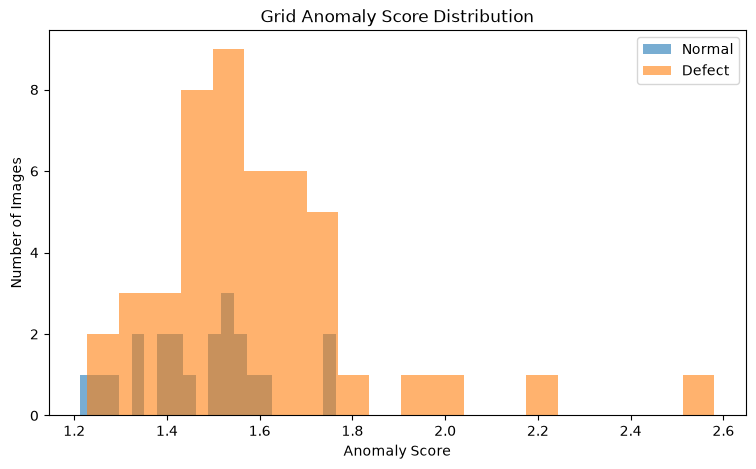

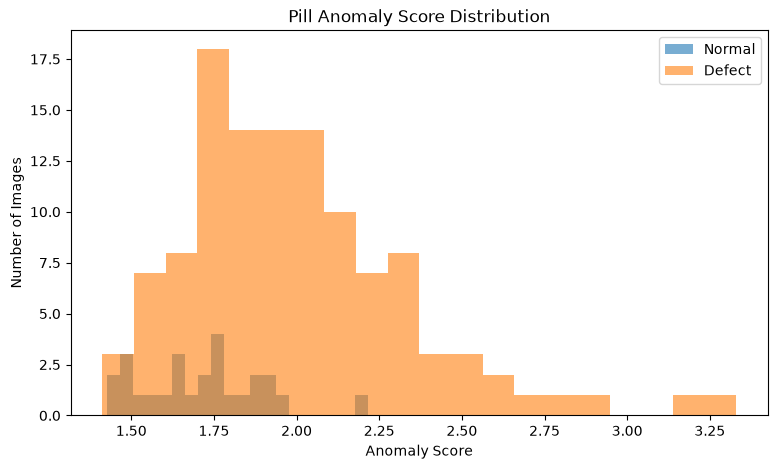

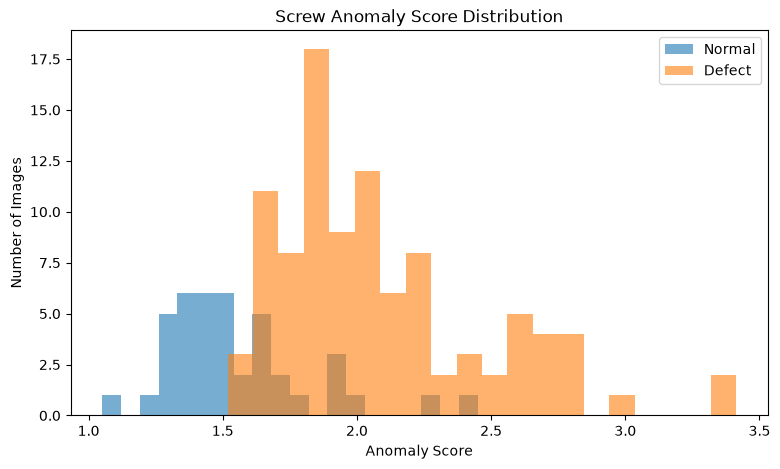

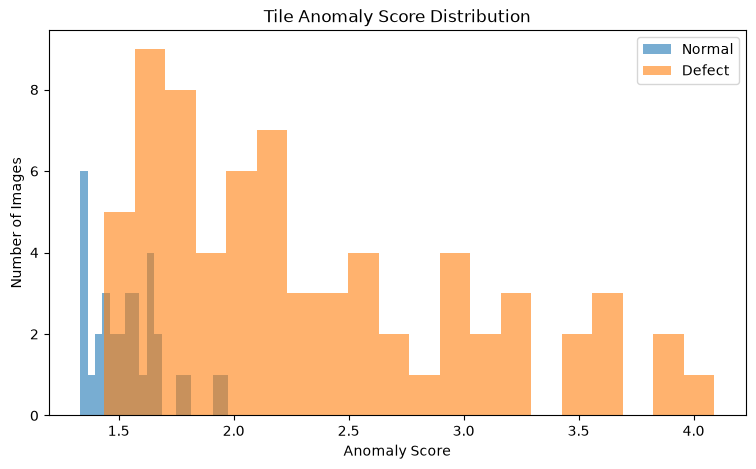

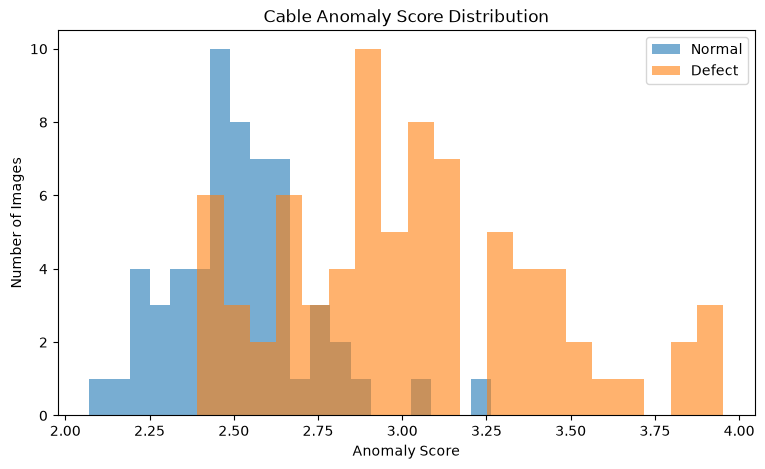

In [25]:
for category in weak_categories:

    normal_scores = score_distributions[
        category
    ]["normal"]

    defect_scores = score_distributions[
        category
    ]["defect"]

    plt.figure(figsize=(9, 5))

    plt.hist(
        normal_scores,
        bins=20,
        alpha=0.6,
        label="Normal"
    )

    plt.hist(
        defect_scores,
        bins=20,
        alpha=0.6,
        label="Defect"
    )

    plt.xlabel("Anomaly Score")
    plt.ylabel("Number of Images")

    plt.title(
        f"{category.capitalize()} "
        "Anomaly Score Distribution"
    )

    plt.legend()
    plt.show()

In [26]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score


def calculate_topk_anomaly_scores(
    image_path,
    normal_features,
    aggregation="max",
    top_percent=5
):
    query_features = extract_local_features(image_path)

    distances = torch.cdist(
        query_features.unsqueeze(0),
        normal_features.to(device).unsqueeze(0)
    )[0]

    nearest_distances = distances.min(dim=1).values

    # Sort patch anomaly distances from highest to lowest
    sorted_distances = torch.sort(
        nearest_distances,
        descending=True
    ).values

    if aggregation == "max":
        return sorted_distances[0].item()

    if aggregation == "top_percent":
        k = max(
            1,
            int(len(sorted_distances) * top_percent / 100)
        )

        return sorted_distances[:k].mean().item()

    raise ValueError(
        f"Unknown aggregation: {aggregation}"
    )

In [27]:
weak_categories = [
    "grid",
    "pill",
    "cable",
    "screw",
    "tile",
]

aggregation_methods = {
    "MAX": ("max", None),
    "TOP-1%": ("top_percent", 1),
    "TOP-5%": ("top_percent", 5),
    "TOP-10%": ("top_percent", 10),
}


aggregation_results = {}


for category in weak_categories:

    print("\n" + "=" * 60)
    print(f"Evaluating: {category}")
    print("=" * 60)

    (
        memory_paths,
        validation_normal_paths,
        validation_defects,
        final_test_normal_paths,
        final_test_defects,
    ) = create_splits(category)

    print("Building feature memory...")

    normal_features = build_feature_memory(
        memory_paths
    )

    y_true = []
    image_paths = []

    # Normal test images
    for image_path in final_test_normal_paths:
        y_true.append(0)
        image_paths.append(image_path)

    # Defect test images
    for image_path, defect_type in final_test_defects:
        y_true.append(1)
        image_paths.append(image_path)

    category_results = {}

    for method_name, (aggregation, top_percent) in aggregation_methods.items():

        scores = []

        print(f"Calculating {method_name} scores...")

        for image_path in image_paths:

            score = calculate_topk_anomaly_scores(
                image_path,
                normal_features,
                aggregation=aggregation,
                top_percent=(
                    top_percent
                    if top_percent is not None
                    else 5
                )
            )

            scores.append(score)

        auc = roc_auc_score(
            y_true,
            scores
        )

        category_results[method_name] = auc

        print(
            f"{method_name:8s} ROC-AUC: {auc:.4f}"
        )

    aggregation_results[category] = category_results


Evaluating: grid
Building feature memory...
  Memory features: 50/211
  Memory features: 100/211
  Memory features: 150/211
  Memory features: 200/211
Calculating MAX scores...
MAX      ROC-AUC: 0.6727
Calculating TOP-1% scores...
TOP-1%   ROC-AUC: 0.6727
Calculating TOP-5% scores...
TOP-5%   ROC-AUC: 0.7548
Calculating TOP-10% scores...
TOP-10%  ROC-AUC: 0.7690

Evaluating: pill
Building feature memory...
  Memory features: 50/213
  Memory features: 100/213
  Memory features: 150/213
  Memory features: 200/213
Calculating MAX scores...
MAX      ROC-AUC: 0.7742
Calculating TOP-1% scores...
TOP-1%   ROC-AUC: 0.7742
Calculating TOP-5% scores...
TOP-5%   ROC-AUC: 0.8166
Calculating TOP-10% scores...
TOP-10%  ROC-AUC: 0.8345

Evaluating: cable
Building feature memory...
  Memory features: 50/179
  Memory features: 100/179
  Memory features: 150/179
Calculating MAX scores...
MAX      ROC-AUC: 0.8882
Calculating TOP-1% scores...
TOP-1%   ROC-AUC: 0.8882
Calculating TOP-5% scores...
TOP-5%  

In [28]:
print("\n")
print("=" * 75)
print("TOP-K AGGREGATION COMPARISON")
print("=" * 75)

print(
    f"{'Category':12s}"
    f"{'MAX':>10s}"
    f"{'TOP-1%':>10s}"
    f"{'TOP-5%':>10s}"
    f"{'TOP-10%':>10s}"
)

print("-" * 75)

for category, results in aggregation_results.items():

    print(
        f"{category:12s}"
        f"{results['MAX']:10.4f}"
        f"{results['TOP-1%']:10.4f}"
        f"{results['TOP-5%']:10.4f}"
        f"{results['TOP-10%']:10.4f}"
    )



TOP-K AGGREGATION COMPARISON
Category           MAX    TOP-1%    TOP-5%   TOP-10%
---------------------------------------------------------------------------
grid            0.6727    0.6727    0.7548    0.7690
pill            0.7742    0.7742    0.8166    0.8345
cable           0.8882    0.8882    0.9451    0.9608
screw           0.8967    0.8967    0.9146    0.9064
tile            0.9135    0.9135    0.9504    0.9596


In [31]:
all_validation_aggregation_results = {}

for category in CATEGORIES:

    print("\n" + "=" * 60)
    print(f"Validation evaluation: {category}")
    print("=" * 60)

    (
        memory_paths,
        validation_normal_paths,
        validation_defects,
        final_test_normal_paths,
        final_test_defects,
    ) = create_splits(category)

    normal_features = build_feature_memory(memory_paths)

    validation_paths = []
    validation_labels = []

    for image_path in validation_normal_paths:
        validation_paths.append(image_path)
        validation_labels.append(0)

    for image_path, defect_type in validation_defects:
        validation_paths.append(image_path)
        validation_labels.append(1)

    category_results = {}

    for method_name, (aggregation, top_percent) in {
        "MAX": ("max", None),
        "TOP-5%": ("top_percent", 5),
        "TOP-10%": ("top_percent", 10),
    }.items():

        scores = []

        for image_path in validation_paths:

            score = calculate_topk_anomaly_scores(
                image_path,
                normal_features,
                aggregation=aggregation,
                top_percent=(
                    top_percent
                    if top_percent is not None
                    else 5
                )
            )

            scores.append(score)

        auc = roc_auc_score(
            validation_labels,
            scores
        )

        category_results[method_name] = auc

        print(
            f"{method_name:8s} "
            f"Validation ROC-AUC: {auc:.4f}"
        )

    all_validation_aggregation_results[category] = (
        category_results
    )


Validation evaluation: bottle
  Memory features: 50/167
  Memory features: 100/167
  Memory features: 150/167
MAX      Validation ROC-AUC: 1.0000
TOP-5%   Validation ROC-AUC: 1.0000
TOP-10%  Validation ROC-AUC: 1.0000

Validation evaluation: cable
  Memory features: 50/179
  Memory features: 100/179
  Memory features: 150/179
MAX      Validation ROC-AUC: 0.9014
TOP-5%   Validation ROC-AUC: 0.9764
TOP-10%  Validation ROC-AUC: 0.9875

Validation evaluation: capsule
  Memory features: 50/175
  Memory features: 100/175
  Memory features: 150/175
MAX      Validation ROC-AUC: 0.9750
TOP-5%   Validation ROC-AUC: 0.9784
TOP-10%  Validation ROC-AUC: 0.9670

Validation evaluation: carpet
  Memory features: 50/224
  Memory features: 100/224
  Memory features: 150/224
  Memory features: 200/224
MAX      Validation ROC-AUC: 0.8369
TOP-5%   Validation ROC-AUC: 0.8679
TOP-10%  Validation ROC-AUC: 0.8774

Validation evaluation: grid
  Memory features: 50/211
  Memory features: 100/211
  Memory featur

In [32]:
print("\n")
print("=" * 75)
print("ALL-CATEGORY VALIDATION TOP-K COMPARISON")
print("=" * 75)

print(
    f"{'Category':15s}"
    f"{'MAX':>10s}"
    f"{'TOP-5%':>10s}"
    f"{'TOP-10%':>10s}"
)

print("-" * 75)

for category, results in all_validation_aggregation_results.items():

    print(
        f"{category:15s}"
        f"{results['MAX']:10.4f}"
        f"{results['TOP-5%']:10.4f}"
        f"{results['TOP-10%']:10.4f}"
    )

print("-" * 75)

print(
    f"{'MACRO AVG':15s}"
    f"{np.mean([r['MAX'] for r in all_validation_aggregation_results.values()]):10.4f}"
    f"{np.mean([r['TOP-5%'] for r in all_validation_aggregation_results.values()]):10.4f}"
    f"{np.mean([r['TOP-10%'] for r in all_validation_aggregation_results.values()]):10.4f}"
)



ALL-CATEGORY VALIDATION TOP-K COMPARISON
Category              MAX    TOP-5%   TOP-10%
---------------------------------------------------------------------------
bottle             1.0000    1.0000    1.0000
cable              0.9014    0.9764    0.9875
capsule            0.9750    0.9784    0.9670
carpet             0.8369    0.8679    0.8774
grid               0.5321    0.5698    0.6264
hazelnut           0.9989    0.9979    0.9968
leather            0.9918    1.0000    1.0000
metal_nut          0.9786    0.9840    0.9733
pill               0.7385    0.8148    0.8222
screw              0.8817    0.8638    0.8594
tile               0.8638    0.8841    0.9043
toothbrush         1.0000    1.0000    1.0000
transistor         0.9535    0.9390    0.9331
wood               0.9945    0.9982    1.0000
zipper             0.9286    0.9563    0.9742
---------------------------------------------------------------------------
MACRO AVG          0.9050    0.9220    0.9281


In [33]:
def calculate_anomaly_score_with_aggregation(
    image_path,
    normal_features,
    top_percent=10
):
    query_features = extract_local_features(image_path)

    distances = torch.cdist(
        query_features.unsqueeze(0),
        normal_features.to(device).unsqueeze(0)
    )[0]

    nearest_distances = distances.min(dim=1).values

    sorted_distances = torch.sort(
        nearest_distances,
        descending=True
    ).values

    k = max(
        1,
        int(len(sorted_distances) * top_percent / 100)
    )

    anomaly_score = sorted_distances[:k].mean().item()

    return anomaly_score

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

final_top10_results = []

for category in CATEGORIES:

    print("\n" + "=" * 60)
    print(f"FINAL TOP-10% EVALUATION: {category}")
    print("=" * 60)

    (
        memory_paths,
        validation_normal_paths,
        validation_defects,
        final_test_normal_paths,
        final_test_defects,
    ) = create_splits(category)

    print(
        f"Memory normals     : {len(memory_paths)}"
    )
    print(
        f"Validation normals : {len(validation_normal_paths)}"
    )
    print(
        f"Validation defects : {len(validation_defects)}"
    )
    print(
        f"Test normals       : {len(final_test_normal_paths)}"
    )
    print(
        f"Test defects       : {len(final_test_defects)}"
    )

    # --------------------------------------------------------
    # Build normal feature memory
    # --------------------------------------------------------

    normal_features = build_feature_memory(
        memory_paths
    )

    # --------------------------------------------------------
    # Validation scores
    # --------------------------------------------------------

    validation_scores = []
    validation_labels = []

    for image_path in validation_normal_paths:

        score = calculate_anomaly_score_with_aggregation(
            image_path,
            normal_features,
            top_percent=10
        )

        validation_scores.append(score)
        validation_labels.append(0)

    for image_path, defect_type in validation_defects:

        score = calculate_anomaly_score_with_aggregation(
            image_path,
            normal_features,
            top_percent=10
        )

        validation_scores.append(score)
        validation_labels.append(1)

    validation_scores = np.array(
        validation_scores
    )

    validation_labels = np.array(
        validation_labels
    )

    # --------------------------------------------------------
    # Select threshold ONLY from validation
    # --------------------------------------------------------

    threshold, validation_f1 = (
        find_best_threshold(
            validation_scores,
            validation_labels
        )
    )

    print(
        f"Validation threshold: "
        f"{threshold:.6f}"
    )

    print(
        f"Validation F1: "
        f"{validation_f1:.4f}"
    )

    # --------------------------------------------------------
    # Final test
    # --------------------------------------------------------

    y_true = []
    y_scores = []

    for image_path in final_test_normal_paths:

        score = calculate_anomaly_score_with_aggregation(
            image_path,
            normal_features,
            top_percent=10
        )

        y_true.append(0)
        y_scores.append(score)

    for image_path, defect_type in final_test_defects:

        score = calculate_anomaly_score_with_aggregation(
            image_path,
            normal_features,
            top_percent=10
        )

        y_true.append(1)
        y_scores.append(score)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    y_pred = (
        y_scores > threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_scores
    )

    print("\nFINAL TEST")

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )

    final_top10_results.append({
        "category": category,
        "threshold": threshold,
        "validation_f1": validation_f1,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    })


FINAL TOP-10% EVALUATION: bottle
Memory normals     : 167
Validation normals : 42
Validation defects : 12
Test normals       : 20
Test defects       : 51
  Memory features: 50/167
  Memory features: 100/167
  Memory features: 150/167
Validation threshold: 0.966538
Validation F1: 1.0000

FINAL TEST
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

FINAL TOP-10% EVALUATION: cable
Memory normals     : 179
Validation normals : 45
Validation defects : 16
Test normals       : 58
Test defects       : 76
  Memory features: 50/179
  Memory features: 100/179
  Memory features: 150/179
Validation threshold: 2.110447
Validation F1: 0.9375

FINAL TEST
Accuracy : 0.8881
Precision: 0.9178
Recall   : 0.8816
F1 Score : 0.8993
ROC-AUC  : 0.9608

FINAL TOP-10% EVALUATION: capsule
Memory normals     : 175
Validation normals : 44
Validation defects : 20
Test normals       : 23
Test defects       : 89
  Memory features: 50/175
  Memory features: 100/175
  Memory fea

In [35]:
print("\n")
print("=" * 80)
print("FINAL 15-CATEGORY TOP-10% RESULTS")
print("=" * 80)

print(
    f"{'Category':15s}"
    f"{'Accuracy':>10s}"
    f"{'Precision':>11s}"
    f"{'Recall':>10s}"
    f"{'F1':>10s}"
    f"{'ROC-AUC':>10s}"
)

print("-" * 80)

for result in final_top10_results:

    print(
        f"{result['category']:15s}"
        f"{result['accuracy']:10.4f}"
        f"{result['precision']:11.4f}"
        f"{result['recall']:10.4f}"
        f"{result['f1']:10.4f}"
        f"{result['roc_auc']:10.4f}"
    )

print("-" * 80)

print(
    f"{'MACRO AVG':15s}"
    f"{np.mean([r['accuracy'] for r in final_top10_results]):10.4f}"
    f"{np.mean([r['precision'] for r in final_top10_results]):11.4f}"
    f"{np.mean([r['recall'] for r in final_top10_results]):10.4f}"
    f"{np.mean([r['f1'] for r in final_top10_results]):10.4f}"
    f"{np.mean([r['roc_auc'] for r in final_top10_results]):10.4f}"
)



FINAL 15-CATEGORY TOP-10% RESULTS
Category         Accuracy  Precision    Recall        F1   ROC-AUC
--------------------------------------------------------------------------------
bottle             1.0000     1.0000    1.0000    1.0000    1.0000
cable              0.8881     0.9178    0.8816    0.8993    0.9608
capsule            0.8393     0.9176    0.8764    0.8966    0.8920
carpet             0.8627     0.9688    0.8378    0.8986    0.9107
grid               0.7206     0.9118    0.6596    0.7654    0.7690
hazelnut           0.9592     1.0000    0.9310    0.9643    0.9974
leather            0.7339     0.7308    0.9870    0.8398    0.9026
metal_nut          0.8265     0.9041    0.8684    0.8859    0.8947
pill               0.7183     0.9524    0.6897    0.8000    0.8345
screw              0.8633     0.8835    0.9286    0.9055    0.9064
tile               0.7353     1.0000    0.6087    0.7568    0.9596
toothbrush         0.8611     0.8519    0.9583    0.9020    0.9688
transistor  